# 22 — Validação Jun-Jul da Valoração dos Modelos

## Objetivo

Criar um quadro comparável de valor monetário dos modelos candidatos usando os cenários econômicos
estimados.

O foco deste notebook é responder:

1. quanto cada política valeria no período final de teste (`S3_junho`);
2. como esse valor se compara com abril e maio;
3. qual modelo é mais defensável sob os valores estimados;
4. quais limites impedem chamar isso de ROI real.

## Por que Jun-Jul?

O dataset de telemetria vai até `2025-06-30 23:59:56.887`. O split final é junho, com horizonte de
predição de 8h; portanto, operacionalmente ele representa decisões tomadas em junho olhando para o
limite final da base, que encosta em `2025-07-01`. Não há dados completos de julho para uma validação
mensal independente.

## Limite central

Estes são os melhores modelos **para os valores estimados descritos**. Para colocar em operação, a
empresa precisa substituir as premissas públicas por custos internos reais: OS, custo de peça/mão de
obra, produção horária por frente/equipamento, despacho e duração real de paradas corretivas e
preditivas.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)

## 1. Cenários Econômicos Estimados

In [ ]:
economic_scenarios = pd.DataFrame([
    {
        "cenario": "conservador",
        "Tipo": "Caminhao",
        "p_acao_confirmada": 0.40,
        "custo_intervencao_preditiva": 15000.0,
        "custo_manutencao_corretiva": 40000.0,
        "impacto_operacional_hora": 15000.0,
        "horas_parada_preditiva": 1.0,
        "horas_parada_corretiva": 3.0,
    },
    {
        "cenario": "base",
        "Tipo": "Caminhao",
        "p_acao_confirmada": 0.655,
        "custo_intervencao_preditiva": 10000.0,
        "custo_manutencao_corretiva": 50000.0,
        "impacto_operacional_hora": 30000.0,
        "horas_parada_preditiva": 1.0,
        "horas_parada_corretiva": 4.0,
    },
    {
        "cenario": "agressivo",
        "Tipo": "Caminhao",
        "p_acao_confirmada": 0.75,
        "custo_intervencao_preditiva": 10000.0,
        "custo_manutencao_corretiva": 80000.0,
        "impacto_operacional_hora": 45000.0,
        "horas_parada_preditiva": 1.0,
        "horas_parada_corretiva": 6.0,
    },
    {
        "cenario": "conservador",
        "Tipo": "Escavadeira",
        "p_acao_confirmada": 0.20,
        "custo_intervencao_preditiva": 35000.0,
        "custo_manutencao_corretiva": 100000.0,
        "impacto_operacional_hora": 60000.0,
        "horas_parada_preditiva": 2.0,
        "horas_parada_corretiva": 6.0,
    },
    {
        "cenario": "base",
        "Tipo": "Escavadeira",
        "p_acao_confirmada": 0.20,
        "custo_intervencao_preditiva": 25000.0,
        "custo_manutencao_corretiva": 150000.0,
        "impacto_operacional_hora": 100000.0,
        "horas_parada_preditiva": 2.0,
        "horas_parada_corretiva": 8.0,
    },
    {
        "cenario": "agressivo",
        "Tipo": "Escavadeira",
        "p_acao_confirmada": 0.40,
        "custo_intervencao_preditiva": 25000.0,
        "custo_manutencao_corretiva": 250000.0,
        "impacto_operacional_hora": 150000.0,
        "horas_parada_preditiva": 2.0,
        "horas_parada_corretiva": 12.0,
    },
])

economic_scenarios["valor_tp_unitario"] = economic_scenarios["p_acao_confirmada"] * (
    economic_scenarios["custo_manutencao_corretiva"]
    + economic_scenarios["impacto_operacional_hora"] * economic_scenarios["horas_parada_corretiva"]
) - (
    economic_scenarios["custo_intervencao_preditiva"]
    + economic_scenarios["p_acao_confirmada"]
    * economic_scenarios["impacto_operacional_hora"]
    * economic_scenarios["horas_parada_preditiva"]
)
economic_scenarios["valor_fp_unitario"] = -(
    economic_scenarios["custo_intervencao_preditiva"]
    + economic_scenarios["impacto_operacional_hora"]
    * economic_scenarios["horas_parada_preditiva"]
)

display(economic_scenarios[[
    "cenario", "Tipo", "valor_tp_unitario", "valor_fp_unitario",
    "p_acao_confirmada", "impacto_operacional_hora",
    "horas_parada_preditiva", "horas_parada_corretiva",
]])

,cenario,Tipo,valor_tp_unitario,valor_fp_unitario,p_acao_confirmada,impacto_operacional_hora,horas_parada_preditiva,horas_parada_corretiva
0,conservador,Caminhao,13000.0,-30000.0,0.400,15000.0,1.0,3.0
1,base,Caminhao,81700.0,-40000.0,0.655,30000.0,1.0,4.0
2,agressivo,Caminhao,218750.0,-55000.0,0.750,45000.0,1.0,6.0
3,conservador,Escavadeira,33000.0,-155000.0,0.200,60000.0,2.0,6.0
4,base,Escavadeira,125000.0,-225000.0,0.200,100000.0,2.0,8.0
5,agressivo,Escavadeira,675000.0,-325000.0,0.400,150000.0,2.0,12.0


## 2. Contagens Auditadas dos Modelos

In [ ]:
policy_counts = pd.DataFrame([
    # CatBoost caminhão-only, faixa robusta 0,390-0,440
    {"politica": "caminhoes_catboost_multijanela", "modelo": "CatBoost", "escopo": "Caminhoes", "split": "S1_abril", "mes_teste": "2025-04", "Tipo": "Caminhao", "TP": 88, "FP": 99, "FN": 275, "threshold_ref": "0,390-0,440"},
    {"politica": "caminhoes_catboost_multijanela", "modelo": "CatBoost", "escopo": "Caminhoes", "split": "S2_maio", "mes_teste": "2025-05", "Tipo": "Caminhao", "TP": 67, "FP": 76, "FN": 213, "threshold_ref": "0,390-0,440"},
    {"politica": "caminhoes_catboost_multijanela", "modelo": "CatBoost", "escopo": "Caminhoes", "split": "S3_junho", "mes_teste": "2025-06", "Tipo": "Caminhao", "TP": 63, "FP": 46, "FN": 220, "threshold_ref": "0,390-0,440"},

    # CatBoost misto, faixa robusta 0,420-0,480
    {"politica": "misto_catboost_multijanela", "modelo": "CatBoost", "escopo": "Misto", "split": "S1_abril", "mes_teste": "2025-04", "Tipo": "Caminhao", "TP": 87, "FP": 94, "FN": 276, "threshold_ref": "0,420-0,480"},
    {"politica": "misto_catboost_multijanela", "modelo": "CatBoost", "escopo": "Misto", "split": "S1_abril", "mes_teste": "2025-04", "Tipo": "Escavadeira", "TP": 0, "FP": 0, "FN": 1, "threshold_ref": "0,420-0,480"},
    {"politica": "misto_catboost_multijanela", "modelo": "CatBoost", "escopo": "Misto", "split": "S2_maio", "mes_teste": "2025-05", "Tipo": "Caminhao", "TP": 58, "FP": 75, "FN": 222, "threshold_ref": "0,420-0,480"},
    {"politica": "misto_catboost_multijanela", "modelo": "CatBoost", "escopo": "Misto", "split": "S2_maio", "mes_teste": "2025-05", "Tipo": "Escavadeira", "TP": 0, "FP": 0, "FN": 7, "threshold_ref": "0,420-0,480"},
    {"politica": "misto_catboost_multijanela", "modelo": "CatBoost", "escopo": "Misto", "split": "S3_junho", "mes_teste": "2025-06", "Tipo": "Caminhao", "TP": 56, "FP": 33, "FN": 227, "threshold_ref": "0,420-0,480"},
    {"politica": "misto_catboost_multijanela", "modelo": "CatBoost", "escopo": "Misto", "split": "S3_junho", "mes_teste": "2025-06", "Tipo": "Escavadeira", "TP": 0, "FP": 0, "FN": 2, "threshold_ref": "0,420-0,480"},

    # RandomForest referência caminhão-only, faixa robusta 0,380-0,390
    {"politica": "caminhoes_rf_referencia", "modelo": "RandomForest", "escopo": "Caminhoes", "split": "S1_abril", "mes_teste": "2025-04", "Tipo": "Caminhao", "TP": 96, "FP": 120, "FN": 267, "threshold_ref": "0,380-0,390"},
    {"politica": "caminhoes_rf_referencia", "modelo": "RandomForest", "escopo": "Caminhoes", "split": "S2_maio", "mes_teste": "2025-05", "Tipo": "Caminhao", "TP": 70, "FP": 103, "FN": 210, "threshold_ref": "0,380-0,390"},
    {"politica": "caminhoes_rf_referencia", "modelo": "RandomForest", "escopo": "Caminhoes", "split": "S3_junho", "mes_teste": "2025-06", "Tipo": "Caminhao", "TP": 50, "FP": 49, "FN": 233, "threshold_ref": "0,380-0,390"},

    # RandomForest referência misto, faixa robusta 0,395-0,450
    {"politica": "misto_rf_referencia", "modelo": "RandomForest", "escopo": "Misto", "split": "S1_abril", "mes_teste": "2025-04", "Tipo": "Caminhao", "TP": 95, "FP": 110, "FN": 268, "threshold_ref": "0,395-0,450"},
    {"politica": "misto_rf_referencia", "modelo": "RandomForest", "escopo": "Misto", "split": "S1_abril", "mes_teste": "2025-04", "Tipo": "Escavadeira", "TP": 0, "FP": 0, "FN": 1, "threshold_ref": "0,395-0,450"},
    {"politica": "misto_rf_referencia", "modelo": "RandomForest", "escopo": "Misto", "split": "S2_maio", "mes_teste": "2025-05", "Tipo": "Caminhao", "TP": 62, "FP": 82, "FN": 218, "threshold_ref": "0,395-0,450"},
    {"politica": "misto_rf_referencia", "modelo": "RandomForest", "escopo": "Misto", "split": "S2_maio", "mes_teste": "2025-05", "Tipo": "Escavadeira", "TP": 0, "FP": 0, "FN": 7, "threshold_ref": "0,395-0,450"},
    {"politica": "misto_rf_referencia", "modelo": "RandomForest", "escopo": "Misto", "split": "S3_junho", "mes_teste": "2025-06", "Tipo": "Caminhao", "TP": 45, "FP": 46, "FN": 238, "threshold_ref": "0,395-0,450"},
    {"politica": "misto_rf_referencia", "modelo": "RandomForest", "escopo": "Misto", "split": "S3_junho", "mes_teste": "2025-06", "Tipo": "Escavadeira", "TP": 0, "FP": 0, "FN": 2, "threshold_ref": "0,395-0,450"},

    # XGBoost caminhão-only como sensibilidade; venceu junho, mas não foi robusto em abril
    {"politica": "caminhoes_xgboost_multijanela_validacao", "modelo": "XGBoost", "escopo": "Caminhoes", "split": "S1_abril", "mes_teste": "2025-04", "Tipo": "Caminhao", "TP": 117, "FP": 254, "FN": 246, "threshold_ref": "validacao"},
    {"politica": "caminhoes_xgboost_multijanela_validacao", "modelo": "XGBoost", "escopo": "Caminhoes", "split": "S2_maio", "mes_teste": "2025-05", "Tipo": "Caminhao", "TP": 76, "FP": 114, "FN": 204, "threshold_ref": "validacao"},
    {"politica": "caminhoes_xgboost_multijanela_validacao", "modelo": "XGBoost", "escopo": "Caminhoes", "split": "S3_junho", "mes_teste": "2025-06", "Tipo": "Caminhao", "TP": 98, "FP": 111, "FN": 185, "threshold_ref": "validacao"},
])

policy_counts["positivos"] = policy_counts["TP"] + policy_counts["FN"]
policy_counts["predicoes_positivas"] = policy_counts["TP"] + policy_counts["FP"]
policy_counts["precision"] = policy_counts["TP"] / policy_counts["predicoes_positivas"].replace(0, np.nan)
policy_counts["recall"] = policy_counts["TP"] / policy_counts["positivos"].replace(0, np.nan)
display(policy_counts)

,politica,modelo,escopo,split,mes_teste,Tipo,TP,FP,FN,threshold_ref,positivos,predicoes_positivas,precision,recall
0,caminhoes_catboost_multijanela,CatBoost,Caminhoes,S1_abril,2025-04,Caminhao,88,99,275,"0,390-0,440",363,187,0.470588,0.242424
1,caminhoes_catboost_multijanela,CatBoost,Caminhoes,S2_maio,2025-05,Caminhao,67,76,213,"0,390-0,440",280,143,0.468531,0.239286
2,caminhoes_catboost_multijanela,CatBoost,Caminhoes,S3_junho,2025-06,Caminhao,63,46,220,"0,390-0,440",283,109,0.577982,0.222615
3,misto_catboost_multijanela,CatBoost,Misto,S1_abril,2025-04,Caminhao,87,94,276,"0,420-0,480",363,181,0.480663,0.239669
4,misto_catboost_multijanela,CatBoost,Misto,S1_abril,2025-04,Escavadeira,0,0,1,"0,420-0,480",1,0,NaN,0.000000
5,misto_catboost_multijanela,CatBoost,Misto,S2_maio,2025-05,Caminhao,58,75,222,"0,420-0,480",280,133,0.436090,0.207143
6,misto_catboost_multijanela,CatBoost,Misto,S2_maio,2025-05,Escavadeira,0,0,7,"0,420-0,480",7,0,NaN,0.000000
7,misto_catboost_multijanela,CatBoost,Misto,S3_junho,2025-06,Caminhao,56,33,227,"0,420-0,480",283,89,0.629213,0.197880
8,misto_catboost_multijanela,CatBoost,Misto,S3_junho,2025-06,Escavadeira,0,0,2,"0,420-0,480",2,0,NaN,0.000000
9,caminhoes_rf_referencia,RandomForest,Caminhoes,S1_abril,2025-04,Caminhao,96,120,267,"0,380-0,390",363,216,0.444444,0.264463


## 3. Aplicação da Função Econômica

In [ ]:
rows = []
for _, count in policy_counts.iterrows():
    for _, scenario in economic_scenarios[economic_scenarios["Tipo"] == count["Tipo"]].iterrows():
        rows.append({
            **count.to_dict(),
            "cenario": scenario["cenario"],
            "valor_tp_unitario": scenario["valor_tp_unitario"],
            "valor_fp_unitario": scenario["valor_fp_unitario"],
            "valor_tp_total": count["TP"] * scenario["valor_tp_unitario"],
            "valor_fp_total": count["FP"] * scenario["valor_fp_unitario"],
            "valor_incremental": count["TP"] * scenario["valor_tp_unitario"] + count["FP"] * scenario["valor_fp_unitario"],
        })
valuation = pd.DataFrame(rows)
display(valuation[[
    "cenario", "politica", "split", "Tipo", "TP", "FP", "FN",
    "valor_tp_unitario", "valor_fp_unitario", "valor_incremental",
]])

,cenario,politica,split,Tipo,TP,FP,FN,valor_tp_unitario,valor_fp_unitario,valor_incremental
0,conservador,caminhoes_catboost_multijanela,S1_abril,Caminhao,88,99,275,13000.0,-30000.0,-1826000.0
1,base,caminhoes_catboost_multijanela,S1_abril,Caminhao,88,99,275,81700.0,-40000.0,3229600.0
2,agressivo,caminhoes_catboost_multijanela,S1_abril,Caminhao,88,99,275,218750.0,-55000.0,13805000.0
3,conservador,caminhoes_catboost_multijanela,S2_maio,Caminhao,67,76,213,13000.0,-30000.0,-1409000.0
4,base,caminhoes_catboost_multijanela,S2_maio,Caminhao,67,76,213,81700.0,-40000.0,2433900.0
5,agressivo,caminhoes_catboost_multijanela,S2_maio,Caminhao,67,76,213,218750.0,-55000.0,10476250.0
6,conservador,caminhoes_catboost_multijanela,S3_junho,Caminhao,63,46,220,13000.0,-30000.0,-561000.0
7,base,caminhoes_catboost_multijanela,S3_junho,Caminhao,63,46,220,81700.0,-40000.0,3307100.0
8,agressivo,caminhoes_catboost_multijanela,S3_junho,Caminhao,63,46,220,218750.0,-55000.0,11251250.0
9,conservador,misto_catboost_multijanela,S1_abril,Caminhao,87,94,276,13000.0,-30000.0,-1689000.0


## 4. Comparação nos Três Splits Temporais

In [ ]:
summary_all = (
    valuation.groupby(["cenario", "politica", "modelo", "escopo", "threshold_ref"])
    .agg(
        splits=("split", "nunique"),
        valor_medio=("valor_incremental", "mean"),
        valor_min=("valor_incremental", "min"),
        valor_max=("valor_incremental", "max"),
        tp_medio=("TP", "mean"),
        fp_medio=("FP", "mean"),
        fn_medio=("FN", "mean"),
        precision_media=("precision", "mean"),
        recall_media=("recall", "mean"),
    )
    .reset_index()
    .sort_values(["cenario", "valor_medio"], ascending=[True, False])
)
display(summary_all)

,cenario,politica,modelo,escopo,threshold_ref,splits,valor_medio,valor_min,valor_max,tp_medio,fp_medio,fn_medio,precision_media,recall_media
2,agressivo,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,3,1.243708e+07,10355000.0,15332500.0,97.000000,159.666667,211.666667,0.394754,0.313344
0,agressivo,caminhoes_catboost_multijanela,CatBoost,Caminhoes,"0,390-0,440",3,1.184417e+07,10476250.0,13805000.0,72.666667,73.666667,236.000000,0.505700,0.234775
1,agressivo,caminhoes_rf_referencia,RandomForest,Caminhoes,"0,380-0,390",3,1.076333e+07,8242500.0,14400000.0,72.000000,90.666667,236.666667,0.451373,0.230380
3,agressivo,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",3,5.476458e+06,0.0,13861250.0,33.500000,33.666667,122.500000,0.515322,0.107449
4,agressivo,misto_rf_referencia,RandomForest,Misto,"0,395-0,450",3,5.182917e+06,0.0,14731250.0,33.666667,39.666667,122.333333,0.462825,0.107025
5,base,caminhoes_catboost_multijanela,CatBoost,Caminhoes,"0,390-0,440",3,2.990200e+06,2433900.0,3307100.0,72.666667,73.666667,236.000000,0.505700,0.234775
6,base,caminhoes_rf_referencia,RandomForest,Caminhoes,"0,380-0,390",3,2.255733e+06,1599000.0,3043200.0,72.000000,90.666667,236.666667,0.451373,0.230380
7,base,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,3,1.538233e+06,-601100.0,3566600.0,97.000000,159.666667,211.666667,0.394754,0.313344
8,base,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",3,1.390283e+06,0.0,3347900.0,33.500000,33.666667,122.500000,0.515322,0.107449
9,base,misto_rf_referencia,RandomForest,Misto,"0,395-0,450",3,1.163900e+06,0.0,3361500.0,33.666667,39.666667,122.333333,0.462825,0.107025


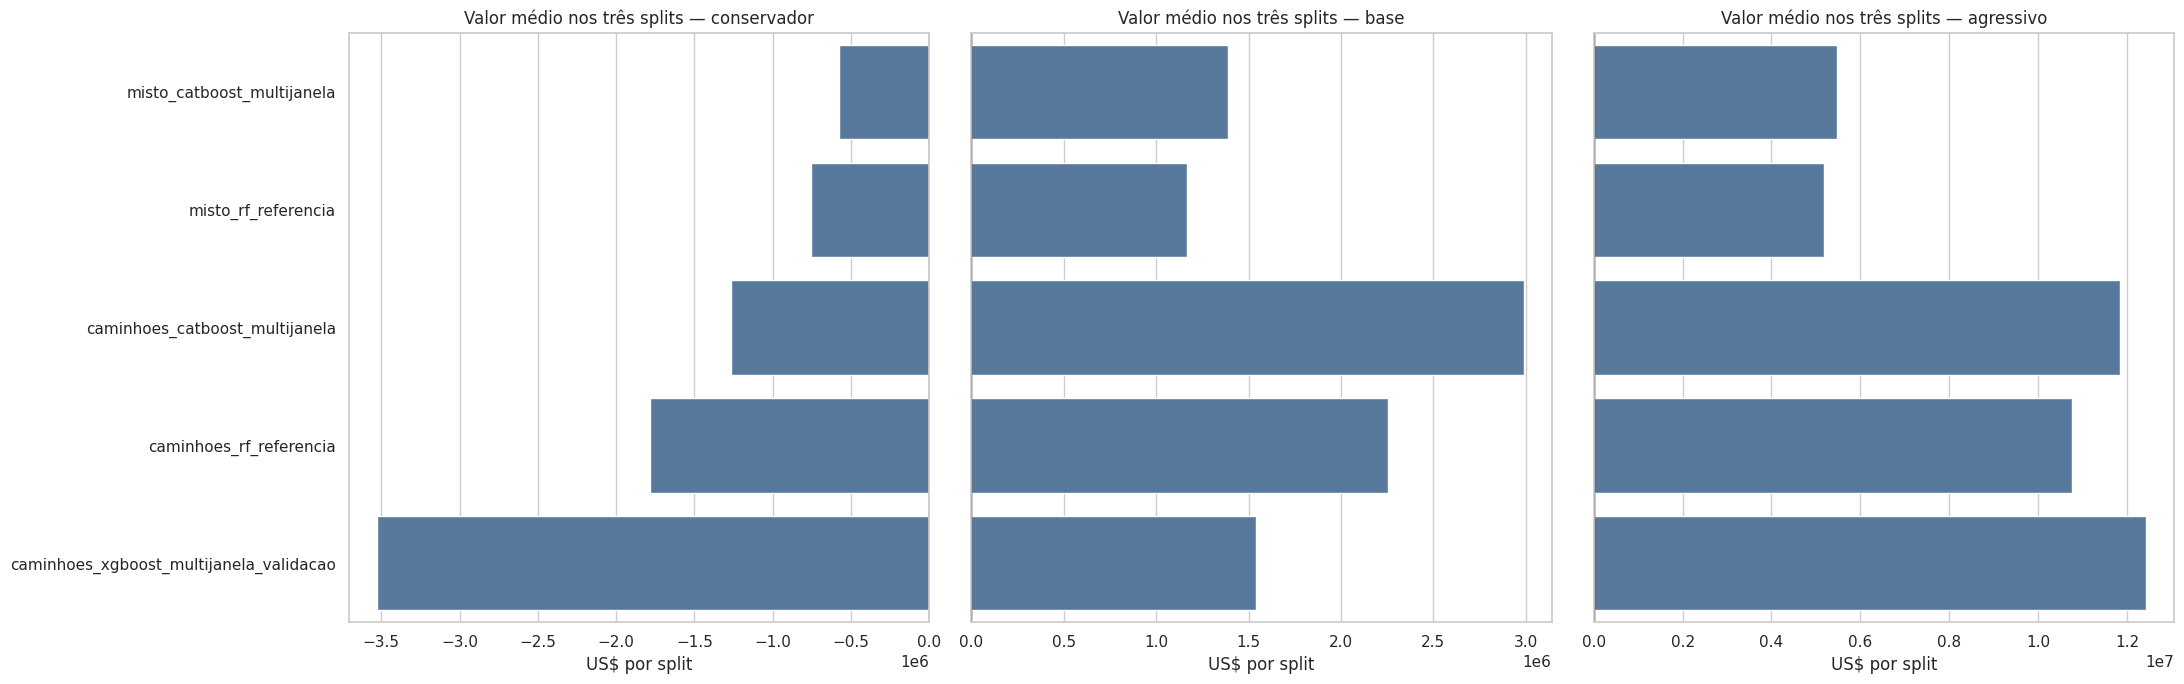

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
for ax, scenario in zip(axes, ["conservador", "base", "agressivo"]):
    data = summary_all[summary_all["cenario"] == scenario].sort_values("valor_medio", ascending=False)
    sns.barplot(data=data, y="politica", x="valor_medio", ax=ax, color="#4C78A8")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Valor médio nos três splits — {scenario}")
    ax.set_xlabel("US$ por split")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Validação Final em Junho com Horizonte até 01/07

In [ ]:
final_month = valuation[valuation["split"] == "S3_junho"].copy()
final_summary = (
    final_month.groupby(["cenario", "politica", "modelo", "escopo", "threshold_ref"])
    .agg(
        valor=("valor_incremental", "sum"),
        TP=("TP", "sum"),
        FP=("FP", "sum"),
        FN=("FN", "sum"),
        precision=("precision", "mean"),
        recall=("recall", "mean"),
    )
    .reset_index()
    .sort_values(["cenario", "valor"], ascending=[True, False])
)
display(final_summary)

print("Ranking de junho por cenário:")
display(final_summary.groupby("cenario").head(10))

,cenario,politica,modelo,escopo,threshold_ref,valor,TP,FP,FN,precision,recall
2,agressivo,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,15332500.0,98,111,185,0.468900,0.346290
0,agressivo,caminhoes_catboost_multijanela,CatBoost,Caminhoes,"0,390-0,440",11251250.0,63,46,220,0.577982,0.222615
3,agressivo,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",10435000.0,56,33,229,0.629213,0.098940
1,agressivo,caminhoes_rf_referencia,RandomForest,Caminhoes,"0,380-0,390",8242500.0,50,49,233,0.505051,0.176678
4,agressivo,misto_rf_referencia,RandomForest,Misto,"0,395-0,450",7313750.0,45,46,240,0.494505,0.079505
7,base,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,3566600.0,98,111,185,0.468900,0.346290
5,base,caminhoes_catboost_multijanela,CatBoost,Caminhoes,"0,390-0,440",3307100.0,63,46,220,0.577982,0.222615
8,base,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",3255200.0,56,33,229,0.629213,0.098940
6,base,caminhoes_rf_referencia,RandomForest,Caminhoes,"0,380-0,390",2125000.0,50,49,233,0.505051,0.176678
9,base,misto_rf_referencia,RandomForest,Misto,"0,395-0,450",1836500.0,45,46,240,0.494505,0.079505


Ranking de junho por cenário:


,cenario,politica,modelo,escopo,threshold_ref,valor,TP,FP,FN,precision,recall
2,agressivo,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,15332500.0,98,111,185,0.468900,0.346290
0,agressivo,caminhoes_catboost_multijanela,CatBoost,Caminhoes,"0,390-0,440",11251250.0,63,46,220,0.577982,0.222615
3,agressivo,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",10435000.0,56,33,229,0.629213,0.098940
1,agressivo,caminhoes_rf_referencia,RandomForest,Caminhoes,"0,380-0,390",8242500.0,50,49,233,0.505051,0.176678
4,agressivo,misto_rf_referencia,RandomForest,Misto,"0,395-0,450",7313750.0,45,46,240,0.494505,0.079505
7,base,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,3566600.0,98,111,185,0.468900,0.346290
5,base,caminhoes_catboost_multijanela,CatBoost,Caminhoes,"0,390-0,440",3307100.0,63,46,220,0.577982,0.222615
8,base,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",3255200.0,56,33,229,0.629213,0.098940
6,base,caminhoes_rf_referencia,RandomForest,Caminhoes,"0,380-0,390",2125000.0,50,49,233,0.505051,0.176678
9,base,misto_rf_referencia,RandomForest,Misto,"0,395-0,450",1836500.0,45,46,240,0.494505,0.079505


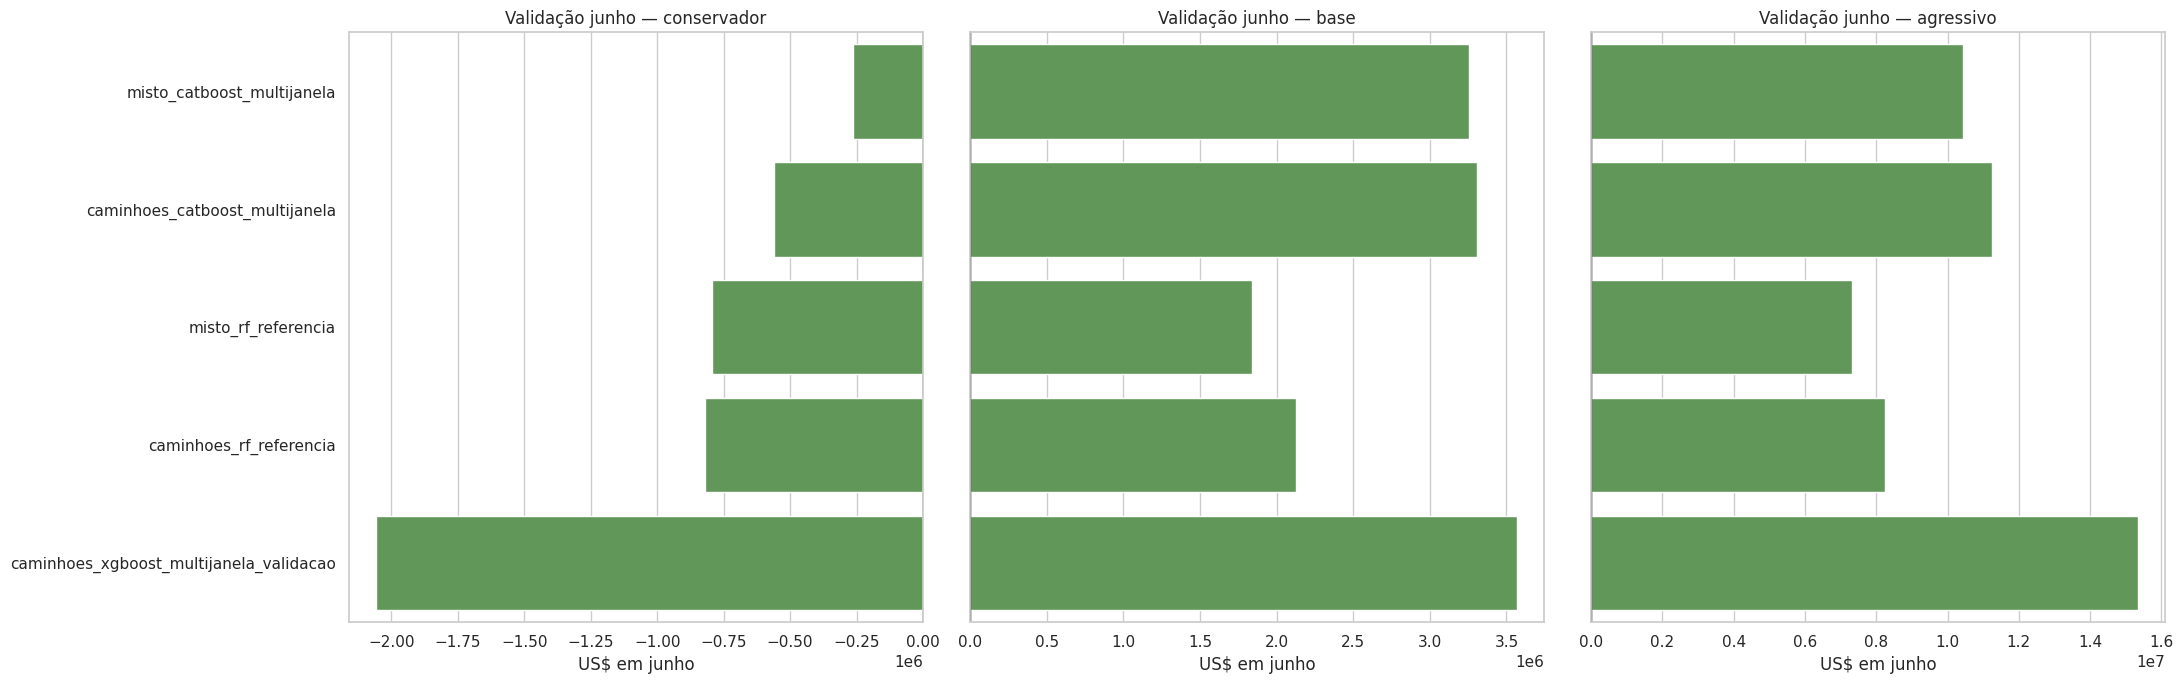

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
for ax, scenario in zip(axes, ["conservador", "base", "agressivo"]):
    data = final_summary[final_summary["cenario"] == scenario].sort_values("valor", ascending=False)
    sns.barplot(data=data, y="politica", x="valor", ax=ax, color="#59A14F")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Validação junho — {scenario}")
    ax.set_xlabel("US$ em junho")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Leitura Auditada

In [ ]:
best_all = summary_all.sort_values(["cenario", "valor_medio"], ascending=[True, False]).groupby("cenario").head(1)
best_june = final_summary.sort_values(["cenario", "valor"], ascending=[True, False]).groupby("cenario").head(1)

print("Melhor política média nos três splits:")
display(best_all)

print("Melhor política na validação final de junho:")
display(best_june)

print("Conclusões para relatório:")
print("- Com os valores estimados, o CatBoost caminhão-only é o candidato operacional mais defensável pela estabilidade média e pela faixa robusta de threshold.")
print("- Na validação final de junho, XGBoost caminhão-only pode vencer nos cenários base/agressivo por maior recall, mas ele foi frágil em abril e deve ficar como sensibilidade, não como recomendação principal.")
print("- No cenário conservador, o custo dos falsos positivos torna políticas mais agressivas economicamente frágeis.")
print("- Escavadeiras seguem sem valor capturado porque os modelos não geram TP nesse tipo; isso não significa baixo impacto, significa falta de suporte do target/modelo atual.")
print("- Estes são os melhores modelos para os valores estimados descritos. Para operação, substituir por custos internos reais.")

Melhor política média nos três splits:


,cenario,politica,modelo,escopo,threshold_ref,splits,valor_medio,valor_min,valor_max,tp_medio,fp_medio,fn_medio,precision_media,recall_media
2,agressivo,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,3,1.243708e+07,10355000.0,15332500.0,97.000000,159.666667,211.666667,0.394754,0.313344
5,base,caminhoes_catboost_multijanela,CatBoost,Caminhoes,"0,390-0,440",3,2.990200e+06,2433900.0,3307100.0,72.666667,73.666667,236.000000,0.505700,0.234775
13,conservador,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",3,-5.745000e+05,-1689000.0,0.0,33.500000,33.666667,122.500000,0.515322,0.107449


Melhor política na validação final de junho:


,cenario,politica,modelo,escopo,threshold_ref,valor,TP,FP,FN,precision,recall
2,agressivo,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,15332500.0,98,111,185,0.468900,0.34629
7,base,caminhoes_xgboost_multijanela_validacao,XGBoost,Caminhoes,validacao,3566600.0,98,111,185,0.468900,0.34629
13,conservador,misto_catboost_multijanela,CatBoost,Misto,"0,420-0,480",-262000.0,56,33,229,0.629213,0.09894


Conclusões para relatório:
- Com os valores estimados, o CatBoost caminhão-only é o candidato operacional mais defensável pela estabilidade média e pela faixa robusta de threshold.
- Na validação final de junho, XGBoost caminhão-only pode vencer nos cenários base/agressivo por maior recall, mas ele foi frágil em abril e deve ficar como sensibilidade, não como recomendação principal.
- No cenário conservador, o custo dos falsos positivos torna políticas mais agressivas economicamente frágeis.
- Escavadeiras seguem sem valor capturado porque os modelos não geram TP nesse tipo; isso não significa baixo impacto, significa falta de suporte do target/modelo atual.
- Estes são os melhores modelos para os valores estimados descritos. Para operação, substituir por custos internos reais.
